# Benchmark Log Summary

This notebook summarizes the benchmark results produced by:

```text
test/bench/benchmarking.py
test/bench/benchmarking.sh
test/bench/logs/
```

It loads all `.csv` files from `logs/`, combines them into one dataframe, computes speedups versus sequential evaluation, and plots runtime, memory, convergence, and correctness metrics.

In [1]:
from pathlib import Path
import re
import json
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)

# ---------------------------------------------------------------------
# Locate logs.
# ---------------------------------------------------------------------
# Best case: notebook is placed in test/bench and logs are in test/bench/logs.
LOG_DIR = Path("logs")

# Fallbacks for common launch locations.
if not LOG_DIR.exists():
    candidates = [
        Path.cwd() / "test" / "bench" / "logs",
        Path.cwd().parent / "logs",
        Path.cwd().parent / "test" / "bench" / "logs",
    ]

    for candidate in candidates:
        if candidate.exists():
            LOG_DIR = candidate
            break

print("Current working directory:", Path.cwd())
print("Using LOG_DIR:", LOG_DIR.resolve())
print("LOG_DIR exists:", LOG_DIR.exists())


Current working directory: /home/cpt/Documents/Github/Parallel-RNN/test/bench
Using LOG_DIR: /home/cpt/Documents/Github/Parallel-RNN/test/bench/logs
LOG_DIR exists: True


In [2]:
# ---------------------------------------------------------------------
# Load all benchmark CSV files.
# ---------------------------------------------------------------------
csv_files = sorted(LOG_DIR.glob("*.csv"))

if len(csv_files) == 0:
    raise FileNotFoundError(
        f"No CSV files found in {LOG_DIR.resolve()}. "
        "Run benchmarking.sh first, or set LOG_DIR manually."
    )

print(f"Found {len(csv_files)} CSV files:")
for path in csv_files:
    print(" -", path.name)

frames = []
for path in csv_files:
    df_i = pd.read_csv(path)
    df_i["source_file"] = path.name
    frames.append(df_i)

df = pd.concat(frames, ignore_index=True)

# Normalize columns that may be absent in older benchmark files.
required_columns = {
    "run_name": "unknown",
    "status": "ok",
    "error_message": "",
    "successful_repeats": np.nan,
    "peak_memory_allocated_mb": np.nan,
    "peak_memory_reserved_mb": np.nan,
    "scan_backend_requested": "unknown",
    "scan_backend_applied": "unknown",
}

for col, default_value in required_columns.items():
    if col not in df.columns:
        df[col] = default_value

# Numeric conversions.
numeric_cols = [
    "seq_len",
    "state_dim",
    "input_dim",
    "successful_repeats",
    "num_iters",
    "initial_merit",
    "final_merit",
    "max_error_vs_sequential",
    "time_min_s",
    "time_mean_s",
    "time_std_s",
    "peak_memory_allocated_mb",
    "peak_memory_reserved_mb",
    "warmup",
    "repeats",
    "seed",
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Extract run kind and backend from run_name when available.
def infer_run_kind(row):
    run_name = str(row.get("run_name", ""))
    source_file = str(row.get("source_file", ""))

    text = run_name + " " + source_file

    if "quick" in text:
        return "quick"
    if "full" in text:
        return "full"
    return "unknown"

def infer_backend(row):
    requested = row.get("scan_backend_requested", None)
    if isinstance(requested, str) and requested not in ["", "unknown", "nan"]:
        return requested

    text = str(row.get("run_name", "")) + " " + str(row.get("source_file", ""))
    if "accel_scan" in text:
        return "accel_scan"
    if "torch" in text:
        return "torch"
    return "unknown"

df["run_kind"] = df.apply(infer_run_kind, axis=1)
df["backend"] = df.apply(infer_backend, axis=1)

# Method ordering.
method_order = [
    "Sequential Evaluation",
    "Full DEER / Newton",
    "Quasi-DEER / Quasi-Newton",
    "Picard",
    "Jacobi",
    "ELK",
    "Quasi-ELK",
]

df["method"] = pd.Categorical(df["method"], categories=method_order, ordered=True)

df.head()


Found 4 CSV files:
 - full_accel_scan_warp_float32_20260531_160403.csv
 - full_torch_warp_float64_20260531_160403.csv
 - quick_accel_scan_warp_float32_20260531_160403.csv
 - quick_torch_warp_float64_20260531_160403.csv


,run_name,seq_len,state_dim,input_dim,dtype,device,scan_backend_requested,scan_backend_applied,method,status,error_message,valid_solution,validation_reason,successful_repeats,num_iters,initial_merit,final_merit,last_update_error,tol,effective_tol,strict_tol,stopping_criterion,max_error_vs_sequential,time_min_s,time_mean_s,time_std_s,peak_memory_allocated_mb,peak_memory_reserved_mb,valid_final_merit_threshold,valid_error_threshold,warmup,repeats,seed,source_file,run_kind,backend
0,full_accel_scan_warp_float32_20260531_160403,1024,4,3,float32,cuda,accel_scan,none,Sequential Evaluation,ok,NaN,True,sequential_baseline,3,NaN,0.000000,0.000000e+00,0.000000,NaN,NaN,NaN,NaN,0.000000e+00,0.046709,0.058049,0.014073,9.654297,22.0,0.000001,0.0001,1,3,0,full_accel_scan_warp_float32_20260531_160403.csv,full,accel_scan
1,full_accel_scan_warp_float32_20260531_160403,1024,4,3,float32,cuda,accel_scan,torch_dense_associative_scan,Full DEER / Newton,ok,NaN,True,passed,3,4.0,266.176514,9.885613e-13,0.000003,1.000000e-12,0.0001,False,update,1.788139e-07,0.026271,0.026686,0.000557,17.726562,22.0,0.000001,0.0001,1,3,0,full_accel_scan_warp_float32_20260531_160403.csv,full,accel_scan
2,full_accel_scan_warp_float32_20260531_160403,1024,4,3,float32,cuda,accel_scan,accelerated_scan.warp,Quasi-DEER / Quasi-Newton,ok,NaN,True,passed,3,10.0,266.176514,2.782532e-09,0.000041,1.000000e-12,0.0001,False,update,1.940504e-05,0.019096,0.020379,0.001123,17.531250,22.0,0.000001,0.0001,1,3,0,full_accel_scan_warp_float32_20260531_160403.csv,full,accel_scan
3,full_accel_scan_warp_float32_20260531_160403,1024,4,3,float32,cuda,accel_scan,torch_cumsum,Picard,ok,NaN,False,final_merit_too_large:1.5300014362782073e+19>=...,3,256.0,266.176514,1.530001e+19,NaN,NaN,NaN,NaN,NaN,1.000000e+08,0.100231,0.105989,0.006679,17.374023,22.0,0.000001,0.0001,1,3,0,full_accel_scan_warp_float32_20260531_160403.csv,full,accel_scan
4,full_accel_scan_warp_float32_20260531_160403,1024,4,3,float32,cuda,accel_scan,none_parallel_map,Jacobi,ok,NaN,True,passed,3,21.0,266.176514,3.732806e-13,NaN,NaN,NaN,NaN,NaN,3.576279e-07,0.008975,0.016218,0.006304,17.358398,22.0,0.000001,0.0001,1,3,0,full_accel_scan_warp_float32_20260531_160403.csv,full,accel_scan


In [3]:
# ---------------------------------------------------------------------
# Compute speedup against the sequential baseline.
# ---------------------------------------------------------------------
# Speedup is computed within each source_file and seq_len group:
#
#     speedup = sequential_time_min / method_time_min.
#
# We use time_min_s because benchmark scripts usually report min/mean/std.
# The minimum over repeats is commonly used for timing because it is less
# affected by OS/GPU scheduling noise.

seq = (
    df[df["method"] == "Sequential Evaluation"]
    .loc[:, ["source_file", "seq_len", "time_min_s", "time_mean_s"]]
    .rename(
        columns={
            "time_min_s": "sequential_time_min_s",
            "time_mean_s": "sequential_time_mean_s",
        }
    )
)

df = df.merge(seq, on=["source_file", "seq_len"], how="left")

df["speedup_min_time"] = df["sequential_time_min_s"] / df["time_min_s"]
df["speedup_mean_time"] = df["sequential_time_mean_s"] / df["time_mean_s"]

# Keep sequential speedup exactly 1 if data exists.
is_seq = df["method"] == "Sequential Evaluation"
df.loc[is_seq, "speedup_min_time"] = 1.0
df.loc[is_seq, "speedup_mean_time"] = 1.0

# Log-safe columns.
for col in ["final_merit", "max_error_vs_sequential"]:
    df[f"log10_{col}"] = np.where(
        df[col].notna() & (df[col] > 0),
        np.log10(df[col]),
        np.nan,
    )

df_summary_cols = [
    "source_file",
    "run_name",
    "run_kind",
    "backend",
    "seq_len",
    "method",
    "status",
    "num_iters",
    "time_min_s",
    "time_mean_s",
    "speedup_min_time",
    "final_merit",
    "max_error_vs_sequential",
    "peak_memory_allocated_mb",
]

df[df_summary_cols].sort_values(["source_file", "seq_len", "method"]).head(30)


/home/cpt/miniconda3/envs/elk/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/cpt/miniconda3/envs/elk/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


,source_file,run_name,run_kind,backend,seq_len,method,status,num_iters,time_min_s,time_mean_s,speedup_min_time,final_merit,max_error_vs_sequential,peak_memory_allocated_mb
0,full_accel_scan_warp_float32_20260531_160403.csv,full_accel_scan_warp_float32_20260531_160403,full,accel_scan,1024,Sequential Evaluation,ok,NaN,0.046709,0.058049,1.000000,0.000000e+00,0.000000e+00,9.654297
1,full_accel_scan_warp_float32_20260531_160403.csv,full_accel_scan_warp_float32_20260531_160403,full,accel_scan,1024,Full DEER / Newton,ok,4.0,0.026271,0.026686,1.777971,9.885613e-13,1.788139e-07,17.726562
2,full_accel_scan_warp_float32_20260531_160403.csv,full_accel_scan_warp_float32_20260531_160403,full,accel_scan,1024,Quasi-DEER / Quasi-Newton,ok,10.0,0.019096,0.020379,2.446023,2.782532e-09,1.940504e-05,17.531250
3,full_accel_scan_warp_float32_20260531_160403.csv,full_accel_scan_warp_float32_20260531_160403,full,accel_scan,1024,Picard,ok,256.0,0.100231,0.105989,0.466016,1.530001e+19,1.000000e+08,17.374023
4,full_accel_scan_warp_float32_20260531_160403.csv,full_accel_scan_warp_float32_20260531_160403,full,accel_scan,1024,Jacobi,ok,21.0,0.008975,0.016218,5.204339,3.732806e-13,3.576279e-07,17.358398
5,full_accel_scan_warp_float32_20260531_160403.csv,full_accel_scan_warp_float32_20260531_160403,full,accel_scan,1024,ELK,ok,4.0,0.075071,0.078216,0.622206,9.877633e-13,1.788139e-07,18.140137
6,full_accel_scan_warp_float32_20260531_160403.csv,full_accel_scan_warp_float32_20260531_160403,full,accel_scan,1024,Quasi-ELK,ok,10.0,0.094388,0.099738,0.494863,2.783460e-09,1.940504e-05,17.586914
7,full_accel_scan_warp_float32_20260531_160403.csv,full_accel_scan_warp_float32_20260531_160403,full,accel_scan,2048,Sequential Evaluation,ok,NaN,0.088859,0.092019,1.000000,0.000000e+00,0.000000e+00,18.306641
8,full_accel_scan_warp_float32_20260531_160403.csv,full_accel_scan_warp_float32_20260531_160403,full,accel_scan,2048,Full DEER / Newton,ok,4.0,0.028671,0.030198,3.099228,2.351964e-12,1.788139e-07,18.199219
9,full_accel_scan_warp_float32_20260531_160403.csv,full_accel_scan_warp_float32_20260531_160403,full,accel_scan,2048,Quasi-DEER / Quasi-Newton,ok,9.0,0.016679,0.018601,5.327593,3.714046e-09,1.239311e-05,17.808594


## High-level status summary

This table checks whether any method failed or partially failed, including OOM cases.


In [4]:
status_summary = (
    df.groupby(["run_kind", "backend", "method", "status"], observed=False)
    .size()
    .reset_index(name="count")
    .sort_values(["run_kind", "backend", "method", "status"])
)

status_summary


,run_kind,backend,method,status,count
0,full,accel_scan,Sequential Evaluation,ok,8
1,full,accel_scan,Full DEER / Newton,ok,8
2,full,accel_scan,Quasi-DEER / Quasi-Newton,ok,8
3,full,accel_scan,Picard,ok,8
4,full,accel_scan,Jacobi,ok,8
5,full,accel_scan,ELK,ok,8
6,full,accel_scan,Quasi-ELK,ok,8
7,full,torch,Sequential Evaluation,ok,8
8,full,torch,Full DEER / Newton,ok,8
9,full,torch,Quasi-DEER / Quasi-Newton,ok,8


## Best runtime by method and sequence length

In [5]:
valid = df[
    (df["status"].fillna("ok").isin(["ok", "partial_oom"]))
    & df["time_min_s"].notna()
].copy()

best = (
    valid.sort_values("time_min_s")
    .groupby(["run_kind", "backend", "seq_len", "method"], observed=False, as_index=False)
    .first()
)

best_table = best[
    [
        "run_kind",
        "backend",
        "seq_len",
        "method",
        "num_iters",
        "time_min_s",
        "speedup_min_time",
        "final_merit",
        "max_error_vs_sequential",
        "peak_memory_allocated_mb",
        "source_file",
    ]
].sort_values(["run_kind", "backend", "seq_len", "method"])

best_table


,run_kind,backend,seq_len,method,num_iters,time_min_s,speedup_min_time,final_merit,max_error_vs_sequential,peak_memory_allocated_mb,source_file
0,full,accel_scan,1024,Sequential Evaluation,NaN,0.046709,1.000000,0.000000e+00,0.000000e+00,9.654297,full_accel_scan_warp_float32_20260531_160403.csv
1,full,accel_scan,1024,Full DEER / Newton,4.0,0.026271,1.777971,9.885613e-13,1.788139e-07,17.726562,full_accel_scan_warp_float32_20260531_160403.csv
2,full,accel_scan,1024,Quasi-DEER / Quasi-Newton,10.0,0.019096,2.446023,2.782532e-09,1.940504e-05,17.531250,full_accel_scan_warp_float32_20260531_160403.csv
3,full,accel_scan,1024,Picard,256.0,0.100231,0.466016,1.530001e+19,1.000000e+08,17.374023,full_accel_scan_warp_float32_20260531_160403.csv
4,full,accel_scan,1024,Jacobi,21.0,0.008975,5.204339,3.732806e-13,3.576279e-07,17.358398,full_accel_scan_warp_float32_20260531_160403.csv
...,...,...,...,...,...,...,...,...,...,...,...
219,quick,torch,131072,Quasi-DEER / Quasi-Newton,NaN,NaN,NaN,NaN,NaN,NaN,NaN
220,quick,torch,131072,Picard,NaN,NaN,NaN,NaN,NaN,NaN,NaN
221,quick,torch,131072,Jacobi,NaN,NaN,NaN,NaN,NaN,NaN,NaN
222,quick,torch,131072,ELK,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Final-sequence summary

In [6]:
largest_rows = []
for (run_kind, backend), group in best.groupby(["run_kind", "backend"], observed=False):
    if group.empty:
        continue

    max_seq_len = group["seq_len"].max()
    largest_rows.append(group[group["seq_len"] == max_seq_len])

largest_summary = pd.concat(largest_rows, ignore_index=True) if largest_rows else pd.DataFrame()

largest_summary[
    [
        "run_kind",
        "backend",
        "seq_len",
        "method",
        "status",
        "num_iters",
        "time_min_s",
        "speedup_min_time",
        "final_merit",
        "max_error_vs_sequential",
        "peak_memory_allocated_mb",
    ]
].sort_values(["run_kind", "backend", "method"])


,run_kind,backend,seq_len,method,status,num_iters,time_min_s,speedup_min_time,final_merit,max_error_vs_sequential,peak_memory_allocated_mb
0,full,accel_scan,131072,Sequential Evaluation,ok,NaN,5.780112,1.000000,0.000000e+00,0.000000e+00,84.751953
1,full,accel_scan,131072,Full DEER / Newton,ok,4.0,0.041011,140.939719,9.582826e-11,2.384186e-07,77.753906
2,full,accel_scan,131072,Quasi-DEER / Quasi-Newton,ok,9.0,0.218250,26.483888,2.333464e-07,1.377612e-05,50.753906
3,full,accel_scan,131072,Picard,ok,256.0,2.935814,1.968828,2.616231e+21,1.000000e+08,32.752930
4,full,accel_scan,131072,Jacobi,ok,18.0,0.008661,667.398030,7.282729e-13,1.788139e-07,30.752930
5,full,accel_scan,131072,ELK,ok,4.0,0.535284,10.798218,9.594080e-11,2.384186e-07,130.753418
6,full,accel_scan,131072,Quasi-ELK,ok,9.0,0.397323,14.547629,2.333467e-07,1.377612e-05,59.754883
7,full,torch,131072,Sequential Evaluation,ok,NaN,5.842310,1.000000,0.000000e+00,0.000000e+00,88.251953
8,full,torch,131072,Full DEER / Newton,ok,4.0,0.057017,102.466551,5.931132e-28,4.440892e-16,138.253906
9,full,torch,131072,Quasi-DEER / Quasi-Newton,ok,14.0,0.104104,56.120008,1.876574e-13,1.227107e-08,84.253906


## Plot helpers

In [7]:
def get_plot_data(run_kind="full", backend="torch"):
    data = best[
        (best["run_kind"] == run_kind)
        & (best["backend"] == backend)
    ].copy()

    data = data.sort_values(["method", "seq_len"])
    return data


def plot_metric(
    data,
    y_col,
    title,
    ylabel,
    logx=True,
    logy=False,
    include_methods=None,
):
    if include_methods is not None:
        data = data[data["method"].astype(str).isin(include_methods)].copy()

    fig, ax = plt.subplots(figsize=(10, 6))

    for method, group in data.groupby("method", observed=False):
        if group.empty:
            continue

        group = group.sort_values("seq_len")

        ax.plot(
            group["seq_len"],
            group[y_col],
            marker="o",
            label=str(method),
        )

    if logx:
        ax.set_xscale("log", base=2)

    if logy:
        ax.set_yscale("log")

    ax.set_title(title)
    ax.set_xlabel("Sequence length T")
    ax.set_ylabel(ylabel)
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()
    plt.show()


def available_runs():
    runs = (
        best[["run_kind", "backend", "source_file"]]
        .drop_duplicates()
        .sort_values(["run_kind", "backend", "source_file"])
    )
    return runs

available_runs()


,run_kind,backend,source_file
0,full,accel_scan,full_accel_scan_warp_float32_20260531_160403.csv
56,full,torch,full_torch_warp_float64_20260531_160403.csv
112,quick,accel_scan,quick_accel_scan_warp_float32_20260531_160403.csv
140,quick,accel_scan,NaN
168,quick,torch,quick_torch_warp_float64_20260531_160403.csv
196,quick,torch,NaN


## Runtime scaling plots

Selected rows: 56


,seq_len,method,time_min_s,speedup_min_time,num_iters,status
56,1024,Sequential Evaluation,0.048746,1.000000,NaN,ok
63,2048,Sequential Evaluation,0.094234,1.000000,NaN,ok
70,4096,Sequential Evaluation,0.181968,1.000000,NaN,ok
77,8192,Sequential Evaluation,0.430772,1.000000,NaN,ok
84,16384,Sequential Evaluation,0.907912,1.000000,NaN,ok
91,32768,Sequential Evaluation,1.450914,1.000000,NaN,ok
98,65536,Sequential Evaluation,2.981322,1.000000,NaN,ok
105,131072,Sequential Evaluation,5.842310,1.000000,NaN,ok
57,1024,Full DEER / Newton,0.031874,1.529358,5.0,ok
64,2048,Full DEER / Newton,0.029107,3.237516,4.0,ok


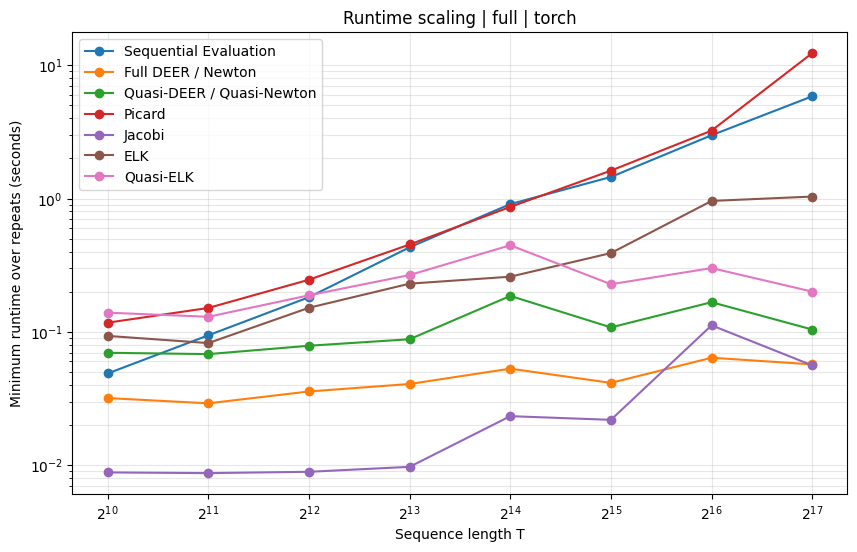

In [8]:
# Change these to inspect different runs.
RUN_KIND = "full"
BACKEND = "torch"

data = get_plot_data(run_kind=RUN_KIND, backend=BACKEND)

print("Selected rows:", len(data))
display(data[["seq_len", "method", "time_min_s", "speedup_min_time", "num_iters", "status"]])

plot_metric(
    data,
    y_col="time_min_s",
    title=f"Runtime scaling | {RUN_KIND} | {BACKEND}",
    ylabel="Minimum runtime over repeats (seconds)",
    logx=True,
    logy=True,
)


## Speedup versus sequential baseline

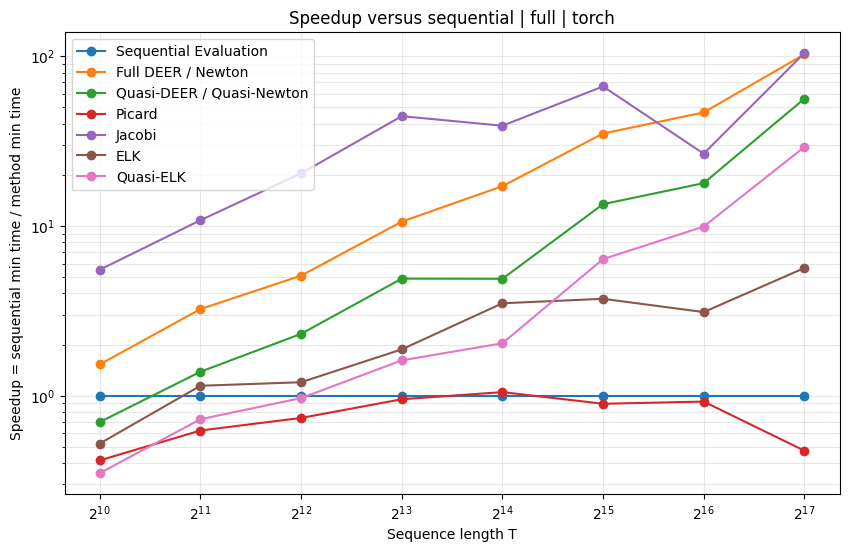

In [9]:
plot_metric(
    data,
    y_col="speedup_min_time",
    title=f"Speedup versus sequential | {RUN_KIND} | {BACKEND}",
    ylabel="Speedup = sequential min time / method min time",
    logx=True,
    logy=True,
)


## Peak memory usage

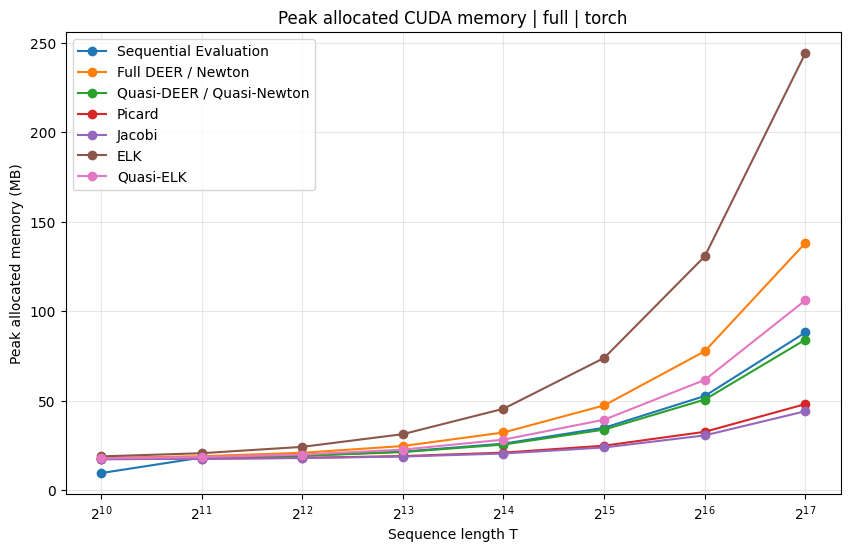

In [10]:
plot_metric(
    data,
    y_col="peak_memory_allocated_mb",
    title=f"Peak allocated CUDA memory | {RUN_KIND} | {BACKEND}",
    ylabel="Peak allocated memory (MB)",
    logx=True,
    logy=False,
)


## Iteration counts

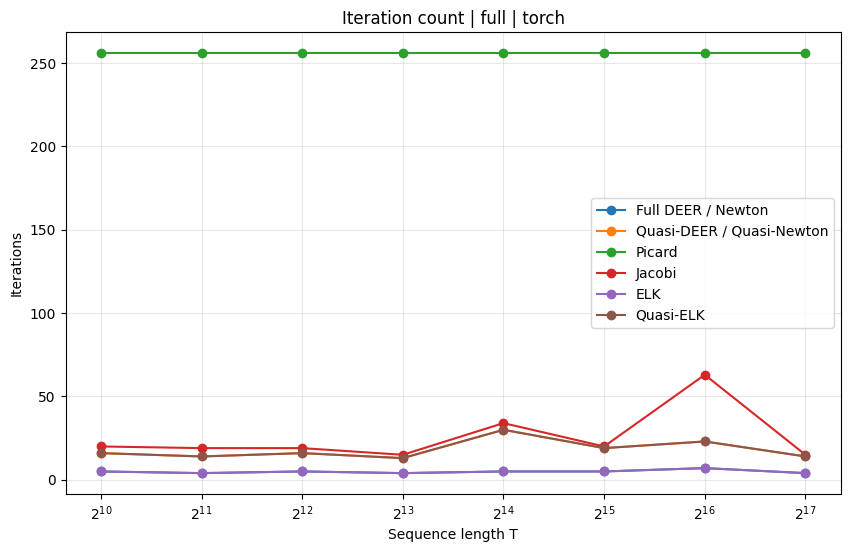

In [11]:
plot_metric(
    data[data["method"] != "Sequential Evaluation"],
    y_col="num_iters",
    title=f"Iteration count | {RUN_KIND} | {BACKEND}",
    ylabel="Iterations",
    logx=True,
    logy=False,
)


## Convergence and correctness

The benchmark records:

$$
\text{merit}(h)=\frac{1}{2}\sum_t \|h_t-f(h_{t-1},u_t)\|_2^2
$$

and the maximum error versus sequential rollout:

$$
\|h_{\text{method}}-h_{\text{seq}}\|_\infty.
$$

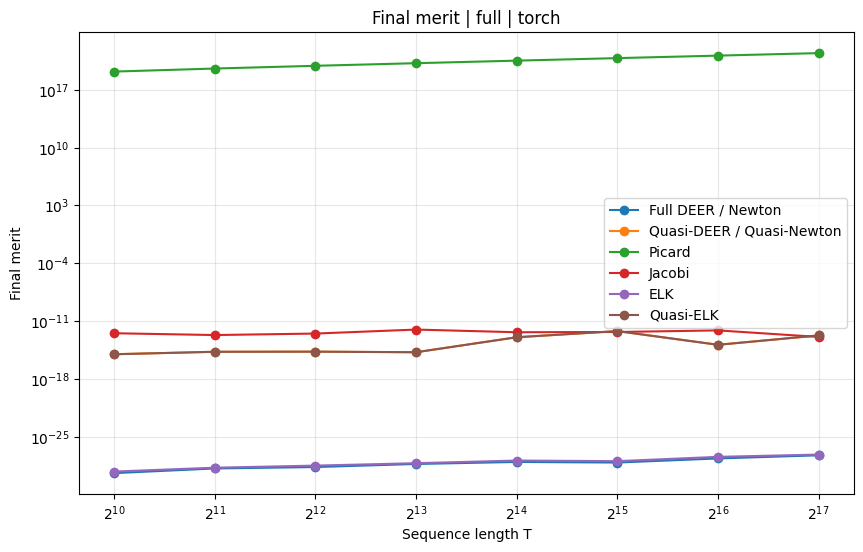

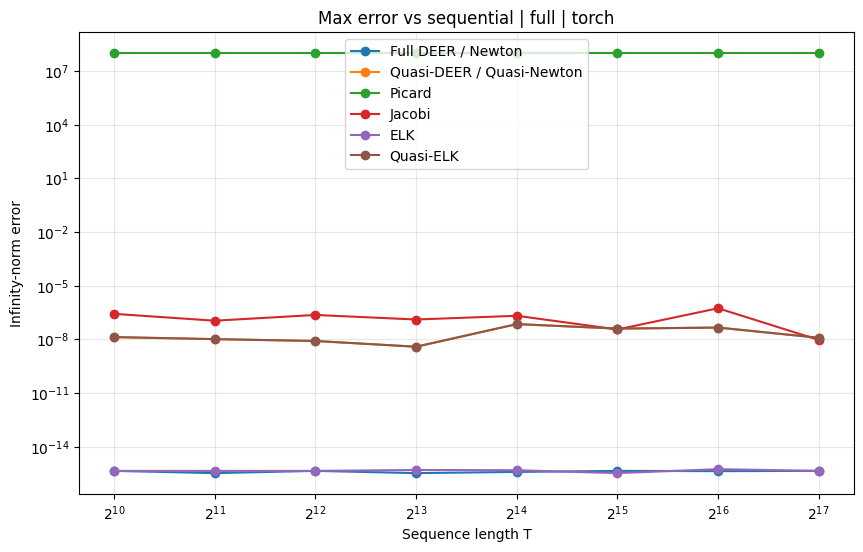

In [12]:
plot_metric(
    data[data["method"] != "Sequential Evaluation"],
    y_col="final_merit",
    title=f"Final merit | {RUN_KIND} | {BACKEND}",
    ylabel="Final merit",
    logx=True,
    logy=True,
)

plot_metric(
    data[data["method"] != "Sequential Evaluation"],
    y_col="max_error_vs_sequential",
    title=f"Max error vs sequential | {RUN_KIND} | {BACKEND}",
    ylabel="Infinity-norm error",
    logx=True,
    logy=True,
)


## Compare torch Vs. accelerated scan

This section compares the same run kind across `torch` and `accel_scan`.

The main comparison of interest is:

```text
Quasi-DEER / Quasi-Newton
Quasi-ELK
```

because only quasi/diagonal methods can use the accelerated scan backend.


In [13]:
COMPARE_RUN_KIND = "full"

compare = best[
    (best["run_kind"] == COMPARE_RUN_KIND)
    & (best["backend"].isin(["torch", "accel_scan"]))
].copy()

compare_pivot = compare.pivot_table(
    index=["seq_len", "method"],
    columns="backend",
    values="time_min_s",
    aggfunc="min",
    observed=False,
).reset_index()

if "torch" in compare_pivot.columns and "accel_scan" in compare_pivot.columns:
    compare_pivot["torch_over_accel_time_ratio"] = (
        compare_pivot["torch"] / compare_pivot["accel_scan"]
    )

compare_pivot.sort_values(["method", "seq_len"])


backend,seq_len,method,accel_scan,torch,torch_over_accel_time_ratio
0,1024,Sequential Evaluation,0.046709,0.048746,1.043603
7,2048,Sequential Evaluation,0.088859,0.094234,1.060493
14,4096,Sequential Evaluation,0.180343,0.181968,1.009010
21,8192,Sequential Evaluation,0.349410,0.430772,1.232855
28,16384,Sequential Evaluation,0.691102,0.907912,1.313717
35,32768,Sequential Evaluation,1.389632,1.450914,1.044099
42,65536,Sequential Evaluation,2.891540,2.981322,1.031050
49,131072,Sequential Evaluation,5.780112,5.842310,1.010761
1,1024,Full DEER / Newton,0.026271,0.031874,1.213252
8,2048,Full DEER / Newton,0.028671,0.029107,1.015195


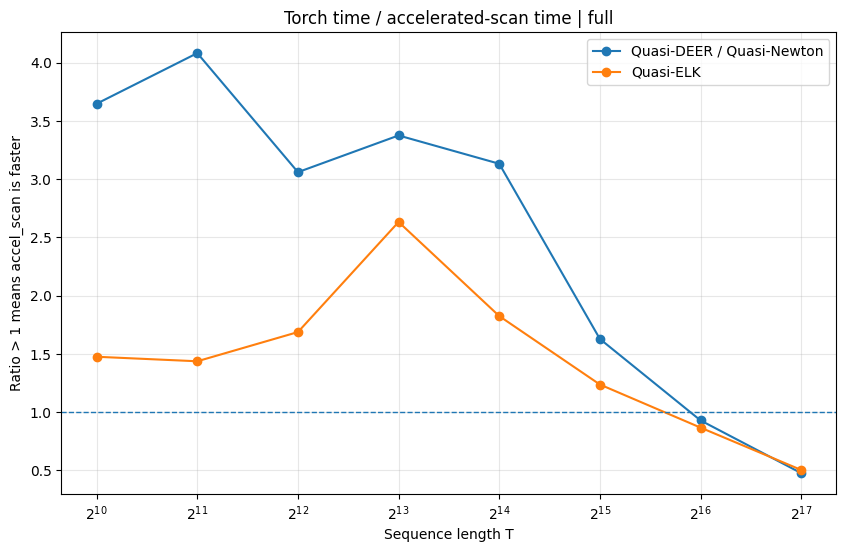

In [14]:
if not compare.empty:
    fig, ax = plt.subplots(figsize=(10, 6))

    target_methods = [
        "Quasi-DEER / Quasi-Newton",
        "Quasi-ELK",
    ]

    for method in target_methods:
        method_data = compare_pivot[compare_pivot["method"].astype(str) == method].copy()
        if method_data.empty or "torch_over_accel_time_ratio" not in method_data.columns:
            continue

        method_data = method_data.sort_values("seq_len")
        ax.plot(
            method_data["seq_len"],
            method_data["torch_over_accel_time_ratio"],
            marker="o",
            label=method,
        )

    ax.axhline(1.0, linestyle="--", linewidth=1)
    ax.set_xscale("log", base=2)
    ax.set_title(f"Torch time / accelerated-scan time | {COMPARE_RUN_KIND}")
    ax.set_xlabel("Sequence length T")
    ax.set_ylabel("Ratio > 1 means accel_scan is faster")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()
    plt.show()
else:
    print("No comparison data found.")


## Automatic textual summary

In [15]:
def format_float(x, digits=4):
    if pd.isna(x):
        return "nan"
    if x == 0:
        return "0"
    if abs(x) < 1e-3 or abs(x) >= 1e4:
        return f"{x:.{digits}e}"
    return f"{x:.{digits}f}"


def summarize_run(run_kind, backend):
    data = get_plot_data(run_kind=run_kind, backend=backend)

    if data.empty:
        print(f"No data for run_kind={run_kind}, backend={backend}")
        return

    max_seq_len = data["seq_len"].max()
    final = data[data["seq_len"] == max_seq_len].copy()

    print("=" * 80)
    print(f"Summary for run_kind={run_kind}, backend={backend}")
    print(f"Largest sequence length: {max_seq_len}")
    print("=" * 80)

    seq_row = final[final["method"] == "Sequential Evaluation"]
    if not seq_row.empty:
        seq_time = seq_row["time_min_s"].iloc[0]
        print(f"Sequential minimum time: {format_float(seq_time)} s")

    final = final.sort_values("speedup_min_time", ascending=False)

    for _, row in final.iterrows():
        method = str(row["method"])
        if method == "Sequential Evaluation":
            continue

        print(
            f"- {method}: "
            f"time={format_float(row['time_min_s'])} s, "
            f"speedup={format_float(row['speedup_min_time'])}x, "
            f"iters={format_float(row['num_iters'], digits=2)}, "
            f"final_merit={format_float(row['final_merit'])}, "
            f"error={format_float(row['max_error_vs_sequential'])}, "
            f"peak_mem={format_float(row['peak_memory_allocated_mb'])} MB, "
            f"status={row['status']}"
        )

    diverged = final[
        (final["final_merit"].notna())
        & (final["final_merit"] > 1e6)
    ]

    if not diverged.empty:
        print()
        print("Likely divergent/high-merit methods:")
        for _, row in diverged.iterrows():
            print(f"- {row['method']}: final_merit={format_float(row['final_merit'])}")


for run_kind in sorted(best["run_kind"].dropna().unique()):
    for backend in sorted(best["backend"].dropna().unique()):
        summarize_run(run_kind, backend)
        print()


Summary for run_kind=full, backend=accel_scan
Largest sequence length: 131072
Sequential minimum time: 5.7801 s
- Jacobi: time=0.0087 s, speedup=667.3980x, iters=18.00, final_merit=7.2827e-13, error=1.7881e-07, peak_mem=30.7529 MB, status=ok
- Full DEER / Newton: time=0.0410 s, speedup=140.9397x, iters=4.00, final_merit=9.5828e-11, error=2.3842e-07, peak_mem=77.7539 MB, status=ok
- Quasi-DEER / Quasi-Newton: time=0.2183 s, speedup=26.4839x, iters=9.00, final_merit=2.3335e-07, error=1.3776e-05, peak_mem=50.7539 MB, status=ok
- Quasi-ELK: time=0.3973 s, speedup=14.5476x, iters=9.00, final_merit=2.3335e-07, error=1.3776e-05, peak_mem=59.7549 MB, status=ok
- ELK: time=0.5353 s, speedup=10.7982x, iters=4.00, final_merit=9.5941e-11, error=2.3842e-07, peak_mem=130.7534 MB, status=ok
- Picard: time=2.9358 s, speedup=1.9688x, iters=256.00, final_merit=2.6162e+21, error=1.0000e+08, peak_mem=32.7529 MB, status=ok

Likely divergent/high-merit methods:
- Picard: final_merit=2.6162e+21

Summary for 

## Save combined summary CSV

In [16]:
summary_path = LOG_DIR / "combined_benchmark_summary.csv"

columns_to_save = [
    "source_file",
    "run_name",
    "run_kind",
    "backend",
    "seq_len",
    "state_dim",
    "input_dim",
    "dtype",
    "device",
    "scan_backend_requested",
    "scan_backend_applied",
    "method",
    "status",
    "successful_repeats",
    "num_iters",
    "initial_merit",
    "final_merit",
    "max_error_vs_sequential",
    "time_min_s",
    "time_mean_s",
    "time_std_s",
    "speedup_min_time",
    "speedup_mean_time",
    "peak_memory_allocated_mb",
    "peak_memory_reserved_mb",
    "warmup",
    "repeats",
    "seed",
]

available_cols = [col for col in columns_to_save if col in df.columns]

df[available_cols].sort_values(
    ["run_kind", "backend", "source_file", "seq_len", "method"]
).to_csv(summary_path, index=False)

print("Saved:", summary_path.resolve())


Saved: /home/cpt/Documents/Github/Parallel-RNN/test/bench/logs/combined_benchmark_summary.csv
